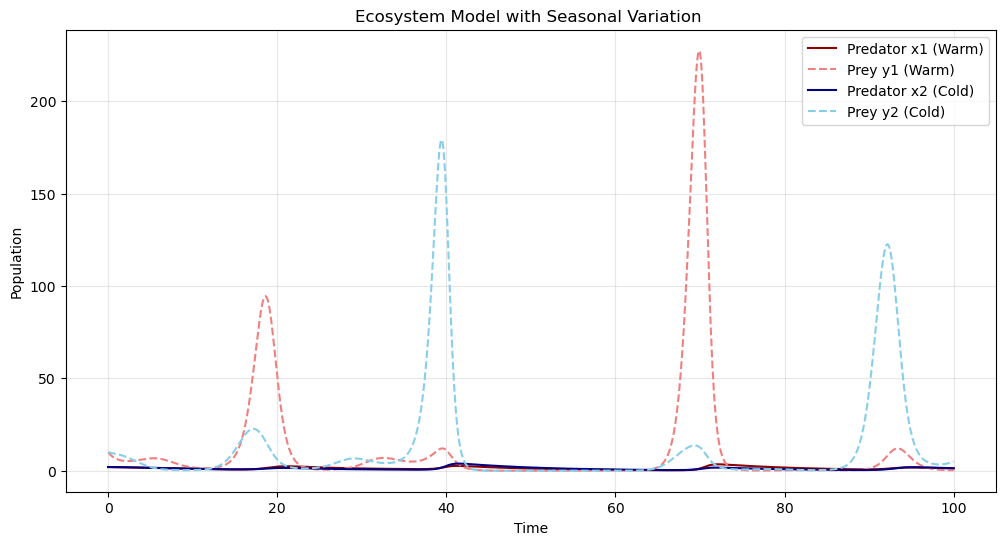

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. モデルの方程式
def ecosystem_model(state, current_time, params):
    # ★ポイント: 引数の名前を 'current_time' に変えて、外の変数 't' と区別しました
    
    # 変数の展開
    x1, y1, x2, y2 = state
    
    # パラメータの展開
    r_x1, r_x2 = params['r_x']
    c1, c2 = params['c']
    d1, d2 = params['d']
    lam11, lam12 = params['lambda_1']
    lam21, lam22 = params['lambda_2']
    
    # --- 季節変動の実装 ---
    # ここで使う変数は、引数として受け取った 'current_time' (今の瞬間) です
    # np.sin() を使って増殖率を振動させます
    
   
    # 周期を調整したい場合は current_time * 0.5 などにします
    r_y1 = 1.0 + 0.5 * np.sin(current_time*0.5)
    r_y2 =  1.0 +0.5 * np.cos((current_time)*0.5)

    # 微分方程式
    dx1dt = -r_x1 * x1 + c1 * lam11 * x1 * y1 + d1 * lam21 * x1 * y2
    dy1dt = r_y1 * y1 - lam11 * x1 * y1 - lam12 * x2 * y1
    dx2dt = -r_x2 * x2 + c2 * lam12 * x2 * y1 + d2 * lam22 * x2 * y2
    dy2dt = r_y2 * y2 - lam21 * x1 * y2 - lam22 * x2 * y2
    
    return [dx1dt, dy1dt, dx2dt, dy2dt]

# 2. パラメータ設定
params = {
    'r_x': [0.1, 0.1],
    
    'c':   [0.01, 0.01],
    'd':   [0.01, 0.01],
    'lambda_1': [0.5, 0.3],
    'lambda_2': [0.3, 0.5]
}

# 3. 初期状態と時間
initial_state = [2.0, 10.0, 2.0, 10.0]
t = np.linspace(0, 100, 1000) # これが「外のリスト」

# 4. シミュレーション実行
# odeintが自動的に 't' から1つずつ数値を取り出し、'current_time' として関数に渡してくれます
solution = odeint(ecosystem_model, initial_state, t, args=(params,))

# 5. 可視化
x1 = solution[:, 0]
y1 = solution[:, 1]
x2 = solution[:, 2]
y2 = solution[:, 3]

plt.figure(figsize=(12, 6))
plt.plot(t, x1, label='Predator x1 (Warm)', color='darkred')
plt.plot(t, y1, label='Prey y1 (Warm)', color='lightcoral', linestyle='--')
plt.plot(t, x2, label='Predator x2 (Cold)', color='navy')
plt.plot(t, y2, label='Prey y2 (Cold)', color='skyblue', linestyle='--')
plt.title('Ecosystem Model with Seasonal Variation ')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. モデルの方程式
def ecosystem_model(state, current_time, params):
    # ★ポイント: 引数の名前を 'current_time' に変えて、外の変数 't' と区別しました
    
    # 変数の展開
    x1, y1, x2, y2 = state
    
    # パラメータの展開
    r_x1, r_x2 = params['r_x']
    c1, c2 = params['c']
    d1, d2 = params['d']
    lam11, lam12 = params['lambda_1']
    lam21, lam22 = params['lambda_2']
    # --- 季節変動の実装 ---
    # ここで使う変数は、引数として受け取った 'current_time' (今の瞬間) です
    # np.sin() を使って増殖率を振動させます
    
   
    # 周期を調整したい場合は current_time * 0.5 などにします
    r_y1 = 0.5+ 0.5 * np.sin(current_time)
    r_y2 = 0.5 +0.5 * np.cos(current_time)

    # 微分方程式
    dx1dt = -r_x1 * x1 + c1 * lam11 * x1 * y1 + d1 * lam21 * x1 * y2
    dy1dt = r_y1 * y1 - lam11 * x1 * y1 - lam12 * x2 * y1
    dx2dt = -r_x2 * x2 + c2 * lam12 * x2 * y1 + d2 * lam22 * x2 * y2
    dy2dt = r_y2 * y2 - lam21 * x1 * y2 - lam22 * x2 * y2
    
    return [dx1dt, dy1dt, dx2dt, dy2dt]


In [22]:
# 2. パラメータ設定
params = {
    'r_x': [0.1, 0.1],
    
    'c':   [0.01, 0.01],
    'd':   [0.01, 0.01],
    'lambda_1': [0.5, 0.3],
    'lambda_2': [0.3, 0.5]
}

# 3. 初期状態と時間
initial_state = [2.0, 10.0, 2.0, 10.0]
t = np.linspace(0, 100, 1000) # これが「外のリスト」

# 4. シミュレーション実行
# odeintが自動的に 't' から1つずつ数値を取り出し、'current_time' として関数に渡してくれます
solution = odeint(ecosystem_model, initial_state, t, args=(params,))

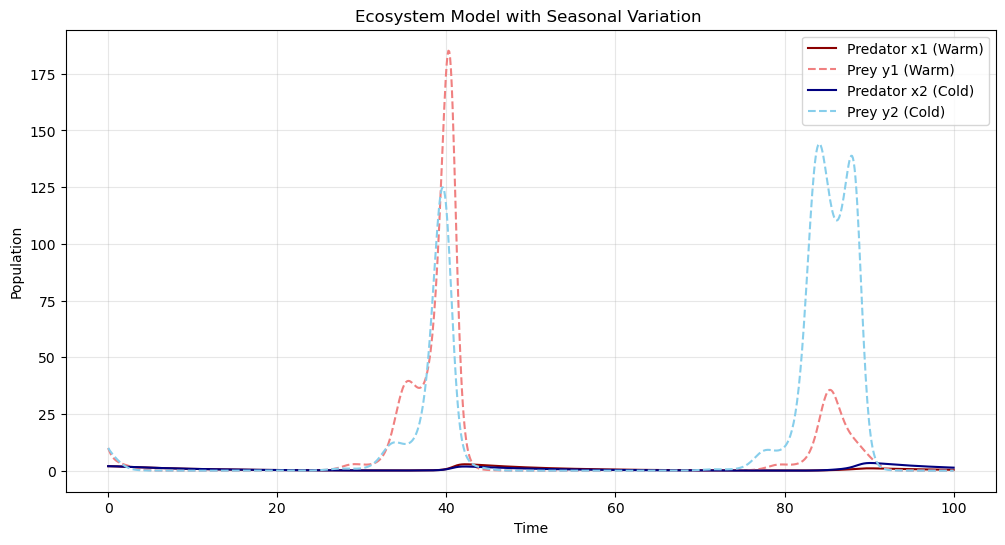

In [23]:
# 5. 可視化
x1 = solution[:, 0]
y1 = solution[:, 1]
x2 = solution[:, 2]
y2 = solution[:, 3]

plt.figure(figsize=(12, 6))
plt.plot(t, x1, label='Predator x1 (Warm)', color='darkred')
plt.plot(t, y1, label='Prey y1 (Warm)', color='lightcoral', linestyle='--')
plt.plot(t, x2, label='Predator x2 (Cold)', color='navy')
plt.plot(t, y2, label='Prey y2 (Cold)', color='skyblue', linestyle='--')
plt.title('Ecosystem Model with Seasonal Variation ')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()